In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyfonts import load_font
from matplotlib import font_manager
#font_manager.findSystemFonts(fontpaths=None, fontext='ttf')

## Load data

In [9]:
df = pd.read_csv("Animal Rescue incidents attended by LFB from Jan 2009.csv")
df.columns

Index(['IncidentNumber', 'DateTimeOfCall', 'CalYear', 'FinYear',
       'TypeOfIncident', 'PumpCount', 'PumpHoursTotal',
       'HourlyNotionalCost(£)', 'IncidentNotionalCost(£)', 'FinalDescription',
       'AnimalGroupParent', 'OriginofCall', 'PropertyType', 'PropertyCategory',
       'SpecialServiceTypeCategory', 'SpecialServiceType', 'WardCode', 'Ward',
       'BoroughCode', 'Borough', 'StnGroundName', 'UPRN', 'Street', 'USRN',
       'PostcodeDistrict', 'Easting_m', 'Northing_m', 'Easting_rounded',
       'Northing_rounded', 'Latitude', 'Longitude'],
      dtype='object')

In [11]:
#clean data
date_format = "%d/%m/%Y %H:%M"
df["DateTimeOfCall"] = pd.to_datetime(df["DateTimeOfCall"], format=date_format)
df["FinalDescription"] = df["FinalDescription"].str.lower()
df["AnimalGroupParent"] = df["AnimalGroupParent"].str.lower()
df["PropertyCategory"] = df["PropertyCategory"].str.lower()
df["Borough"] = df["Borough"].str.lower().fillna("unknown")
df["Month"] = df["DateTimeOfCall"].dt.month

## Day 1: Fractions

In [ ]:
title_font = load_font(
  "https://github.com/google/fonts/blob/7a52693c6f33db2c0fae7506763a6614b0c66457/apache/permanentmarker/PermanentMarker-Regular.ttf?raw=true"
)
label_font = load_font(
  "https://github.com/google/fonts/blob/7a52693c6f33db2c0fae7506763a6614b0c66457/ofl/coveredbyyourgrace/CoveredByYourGrace.ttf?raw=true"
)
subtitle_font = load_font(
  "https://github.com/googlefonts/opensans/blob/main/fonts/ttf/OpenSans-Regular.ttf?raw=true"
)

In [ ]:
#load and process svg
#code: https://petercbsmith.github.io/marker-tutorial.html
import matplotlib as mpl
from svgpathtools import svg2paths
from svgpath2mpl import parse_path
dog_outline_svg = parse_path("""M770.664 204.866C762.462 145.497 736.643 90.8126 695.998 46.7246C669.237 17.6949 632.762 1.11879 593.291 0.0522548C559.8 -0.836807 527.923 9.53614 501.749 29.4893C434.778 14.0913 365.218 14.0913 298.248 29.4893C272.068 9.53445 240.175 -0.841878 206.709 0.053945C167.238 1.11879 130.763 17.6949 104 46.7246C63.3567 90.8126 37.5367 145.498 29.3357 204.866C21.1263 264.293 31.195 323.907 58.4533 377.268C114.724 487.42 180.529 647.421 174.459 784.112C174.165 790.734 178.194 796.785 184.419 799.069C186.132 799.697 187.903 800 189.654 800C194.267 800 198.746 797.897 201.689 794.098C202.748 792.727 227.96 759.916 253.356 706.844C270.361 671.304 289.724 621.429 299.112 564.251C305.187 571.905 312.62 578.377 320.992 583.338C334.811 611.272 365.124 629.692 398.203 629.692C430.429 629.692 459.532 612.754 473.993 586.077C484.42 580.866 493.627 573.402 500.892 564.253C510.279 621.432 529.642 671.306 546.648 706.846C572.042 759.918 597.253 792.728 598.315 794.099C601.254 797.901 605.735 800.003 610.348 800.002C612.099 800.002 613.87 799.699 615.582 799.07C621.807 796.787 625.835 790.737 625.543 784.113C619.475 647.421 685.279 487.422 741.55 377.27C768.805 323.909 778.875 264.293 770.664 204.866ZM204.188 734.524C195.55 604.276 136.728 463.618 85.546 363.428C61.1374 315.644 52.12 262.254 59.4742 209.031C66.8233 155.841 89.9542 106.848 126.37 67.3454C147.518 44.4056 176.342 31.308 207.532 30.4663C226.336 29.9609 244.509 33.9532 260.88 41.9632C250.536 48.234 241.958 57.27 236.32 68.1601L195.685 146.626C180.863 175.246 178.096 209.235 188.092 239.877L274.294 504.105C272.19 601.034 232.081 686.499 204.188 734.524ZM371.971 593.102C381.725 590.976 390.738 586.221 398.176 579.114C398.802 578.517 399.408 577.91 400 577.29C400.592 577.909 401.2 578.517 401.824 579.114C408.669 585.655 416.845 590.215 425.707 592.558C417.546 596.863 408.12 599.266 398.202 599.266C388.841 599.266 379.868 597.037 371.971 593.102ZM400 519.148C380.897 519.148 365.355 505.224 365.355 488.107C365.355 480.904 365.355 476.146 400 476.146C434.646 476.146 434.646 480.904 434.646 488.107C434.645 505.224 419.103 519.148 400 519.148ZM441.015 563.929C434.231 564.23 427.764 561.818 422.842 557.117C419.994 554.396 417.915 551.117 416.644 547.527C444.485 540.561 465.069 516.567 465.069 488.108C465.069 465.256 451.922 455.215 440.892 450.813C429.109 446.113 414.825 445.724 399.998 445.724C385.172 445.724 370.888 446.113 359.107 450.813C348.078 455.215 334.93 465.256 334.93 488.108C334.93 516.567 355.513 540.561 383.353 547.527C382.084 551.117 380.003 554.396 377.155 557.117C372.233 561.819 365.761 564.224 358.983 563.929C338.841 563.013 321.109 549.519 314.855 530.352L311.381 519.704C302.479 491.715 305.844 461.186 320.688 435.818C333.804 413.4 341.278 387.835 342.302 361.883C342.323 361.371 342.316 360.859 342.285 360.347C342.285 360.347 331.497 185.496 331.493 185.459C331.098 179.7 327.44 174.481 321.8 172.307C287.142 158.954 259.312 181.933 249.439 195.952C245.594 201.41 245.758 208.737 249.843 214.019C250.472 214.832 254.001 219.203 261.704 225.358C268.89 231.103 277.71 234.153 286.724 234.153C289.31 234.153 291.915 233.901 294.499 233.39C297.746 232.75 300.858 231.705 303.79 230.326L311.871 361.43C310.932 382.153 304.908 402.545 294.43 420.453C290.838 426.594 287.769 432.97 285.221 439.512L217.016 230.443C209.531 207.498 211.603 182.048 222.7 160.617L263.335 82.1519C267.881 73.3711 275.951 66.8029 285.47 64.1306C322.934 53.614 361.466 48.3574 400 48.3574C438.534 48.3574 477.068 53.614 514.53 64.1306C524.051 66.8029 532.119 73.3711 536.667 82.1519L577.3 160.617C588.398 182.048 590.471 207.498 582.984 230.443L514.779 439.511C512.231 432.968 509.162 426.591 505.57 420.452C495.092 402.544 489.068 382.151 488.129 361.43L496.232 230.412C499.179 231.796 502.31 232.841 505.577 233.478C508.131 233.975 510.7 234.22 513.256 234.22C522.204 234.22 530.951 231.218 538.07 225.56C545.95 219.296 549.552 214.84 550.194 214.01C554.281 208.728 554.445 201.399 550.598 195.942C540.725 181.923 512.887 158.942 478.237 172.297C472.595 174.472 468.938 179.693 468.542 185.455C468.539 185.489 457.713 360.342 457.713 360.342C457.679 360.854 457.676 361.368 457.694 361.882C458.719 387.832 466.193 413.398 479.309 435.816C494.159 461.196 497.523 491.739 488.605 519.736L485.142 530.352C478.89 549.519 461.156 563.013 441.015 563.929ZM595.807 734.601C567.913 686.651 527.807 601.261 525.708 504.111L611.909 239.877C621.905 209.237 619.137 175.246 604.317 146.626L563.684 68.1601C558.045 57.2733 549.472 48.2407 539.131 41.97C555.5 33.9617 573.668 29.9609 592.47 30.4663C623.658 31.3097 652.482 44.4056 673.63 67.3454C710.046 106.848 733.178 155.841 740.528 209.031C747.882 262.254 738.864 315.644 714.454 363.428C663.262 463.639 604.428 604.329 595.807 734.601Z""")
bird_outline_svg = parse_path("""M775.856 260.99C741.564 261.517 707.424 263.928 673.236 262.552C691.486 223.504 705.477 184.542 703.024 139.888C702.304 126.737 688.54 122.312 678.907 129.898C650.643 152.147 619.4 170.099 590.688 191.676C568.365 170.94 542.972 154.699 515.271 145.336C530.083 102.297 516.195 36.1608 480.2 10.0468C444.636 -15.7564 424.256 12.4622 413.264 45.9468C402.786 27.8414 387.577 13.8419 365.552 13.8626C341.584 13.8875 332.399 33.128 329.785 54.9705C322.137 49.1867 313.204 45.4041 302.61 45.0768C281.928 44.4304 266.341 64.8186 260.177 82.257C243.505 129.418 265.579 195.641 322.418 196.213C210.36 308.669 223.821 533.673 25.8716 536.701C17.4197 536.83 12.5515 542.22 10.9316 548.538C9.50636 551.393 9.12106 554.836 10.9067 558.498C10.973 558.639 11.0683 558.755 11.1346 558.896C11.8099 560.893 12.8664 562.733 14.2751 564.303C61.0797 652.269 166.194 684.005 268.579 691.426C269.3 708.503 267.125 725.204 261.755 741.412C241.678 746.057 220.469 765.194 209.585 779.645C200.619 791.548 217.349 804.379 228.49 798.55C238.363 793.379 247.958 787.699 257.608 782.131C261.987 779.603 269.175 776.807 274.93 773.061C275.987 773.799 277.076 774.503 278.133 775.228C287.857 781.952 299.047 792.352 311.435 786.348C315.06 784.592 318.213 779.404 317.753 775.332C317.111 769.639 315.081 766.287 310.892 762.463C308.282 760.077 305.154 759.331 302.179 759.609C297.39 756.195 292.029 751.148 286.336 747.01C288.863 729.165 288.909 709.581 285.516 692.366C327.523 694.351 368.535 692.635 404.187 689.172C420.154 687.618 435.612 685.124 450.693 682.017C455.056 697.077 453.916 713.144 456.601 728.366C455.777 729.153 454.824 729.787 454.206 730.785C446.703 742.904 434.493 751.099 426.99 763.366C419.935 774.897 434.187 789.949 445.874 782.247C454.67 776.446 460.856 768.695 466.979 760.359C477.66 773.782 491.975 790.446 503.878 785.868C512.512 782.553 516.154 772.423 509.33 765.198C517.219 775.394 509.111 763.644 507.652 762.219C503.957 758.627 500.439 754.873 496.922 751.099C492.617 746.487 488.374 741.81 484.144 737.124C485.18 734.34 485.553 731.498 484.724 728.643C479.972 712.29 477.354 693.684 471.015 677.248C587.755 646.809 671.881 566.925 686.568 434.736C688.006 421.822 688.142 408.381 687.231 394.697C729.428 374.184 768.473 324.127 788.6 283.222C793.381 273.494 787.701 260.808 775.856 260.99ZM674.043 164.257C670.915 197.651 658.457 227.435 643.397 258.161C631.916 238.696 618.505 220.508 603.366 204.404C627.177 191.49 650.469 177.602 674.043 164.257ZM283.722 103.076C285.806 92.362 290.761 80.6039 300.443 74.8159C313.888 66.7866 330.133 101.812 333.878 109.229C341.787 124.898 363.592 113.384 360.63 97.951C359.192 90.4686 350.082 39.7653 369.923 43.5811C392.151 47.8568 399.484 88.4799 402.844 105.79C406.233 123.257 430.727 117.531 432.016 101.841C433.474 84.0468 442.067 2.98283 471.943 44.4967C492.998 73.747 488.751 105.624 486.054 138.247C465.335 135.115 443.646 135.691 421.198 141.085C384.345 149.939 355.513 166.263 331.885 187.293C331.583 185.325 330.75 183.465 328.575 182.296C296.279 164.937 276.202 141.706 283.722 103.076ZM443.256 650.347C325.986 676.08 127.655 673.987 44.4079 568.562C132.059 563.495 195.275 524.691 230.611 438.46C261.357 363.433 277.142 285.339 333.775 223.93C425.789 124.152 559.06 183.092 619.91 281.905C718.532 442.04 608.947 613.987 443.256 650.347ZM682.885 362.045C678.34 338.098 670.7 314.01 660.292 290.854C690.044 293.186 719.763 292.205 749.547 291.227C731.173 318.401 707.395 340.062 682.885 362.045Z M481.244 439.931C469.453 426.362 450.879 445.831 461.788 459.391C483.158 485.957 485.88 518.961 453.92 537.882C426.501 554.115 412.212 536.594 408.649 514.068C409.772 504.713 409.879 495.681 409.009 487.701C407.493 473.809 384.726 467.719 382.34 484.092C382.166 485.294 382.096 486.508 381.959 487.718C381.926 487.713 381.888 487.709 381.855 487.701C381.876 487.896 381.876 488.103 381.897 488.298C380.948 496.982 380.948 505.736 381.951 514.175C379.477 537.7 369.273 560.214 344.393 567.356C301.21 579.744 329.42 507.807 336.356 494.467C343.022 481.635 325.037 465.68 315.309 478.23C304.839 491.753 246.218 562.981 249.069 507.903C251.273 465.274 290.537 436.546 330.22 434.375C337.122 433.998 339.446 423.027 331.935 421.706C274.114 411.559 224.678 456.81 222.677 514.441C222.014 533.561 232.741 556.128 254.418 556.642C269.179 556.999 282.645 550.088 294.751 540.426C292.629 566.838 301.367 590.483 334.959 594.717C365.159 598.521 385.601 579.28 397.367 554.173C409.983 569.681 429.99 576.74 457.861 566.213C514.393 544.863 517.107 481.2 481.244 439.931Z M442.978 238.957C400.938 250.301 393.435 301.663 429.708 325.664C434.862 329.074 443.107 323.357 440.662 317.25C431.995 295.627 423.398 273.788 453.299 267.454C481.112 261.562 500.385 283.632 504.901 308.665C508.452 328.349 538.564 320.025 534.893 300.395C526.847 257.34 486.784 227.137 442.978 238.957Z""")
cat_outline_svg = parse_path("""M673.065 198.292C606.84 58.7158 567.201 58.7158 550.062 58.7158C547.02 58.7158 543.994 58.9768 541.023 59.4689C512.742 64.1783 476.376 93.8924 432.739 147.874H367.225C323.617 93.8924 287.222 64.1768 258.942 59.4689C255.987 58.9768 252.959 58.7158 249.945 58.7158H249.555C232.198 58.7158 192.661 59.7299 126.9 198.292C53.4186 257.2 -50.7658 400.791 28.2671 572.022C106.386 741.285 327.369 741.285 399.997 741.285C472.609 741.285 693.608 741.285 771.726 572.038C850.773 400.791 746.576 257.2 673.065 198.292ZM731.336 553.377C667.039 692.649 479.131 696.777 399.998 696.777C320.895 696.777 132.958 692.649 68.6889 553.377C-20.3251 360.514 162.628 226.992 162.628 226.992C162.628 226.992 219.739 103.222 249.933 103.222L251.642 103.367C281.314 108.308 345.611 192.381 345.611 192.381H454.386C454.386 192.381 518.683 108.308 548.354 103.367L550.064 103.222C580.228 103.222 637.369 226.992 637.369 226.992C637.369 226.992 820.35 360.514 731.336 553.377Z M121.887 491.18L283.978 503.944L285.137 489.152L123.047 476.402L121.887 491.18Z M119.062 555.463L120.64 570.211L278.82 553.333L277.24 538.583L119.062 555.463Z M516.045 503.944L678.106 491.18L676.948 476.402L514.886 489.152L516.045 503.944Z M521.187 553.333L679.369 570.211L680.947 555.463L522.767 538.583L521.187 553.333Z M495.659 575.73C483.186 578.714 472.667 579.961 463.903 579.961C452.269 579.961 443.853 577.788 437.55 574.614C428.205 569.835 422.772 562.706 419.048 553.521C415.412 544.408 414.094 533.441 414.108 523.588C414.108 517.416 414.628 511.983 415.194 507.449L441.315 481.327C446.125 476.516 447.573 469.274 444.966 462.999C442.358 456.711 436.244 452.611 429.434 452.611H370.555C363.601 452.611 357.372 456.9 354.88 463.391C352.358 469.881 354.126 477.241 359.284 481.906L384.434 504.681C385.159 509.549 385.883 516.127 385.869 523.616C385.939 536.8 383.476 551.766 376.565 562.024C373.103 567.211 368.728 571.427 362.44 574.613C356.151 577.786 347.722 579.96 336.101 579.96C327.35 579.96 316.819 578.713 304.342 575.716C297.562 574.092 290.753 578.28 289.13 585.046C287.522 591.825 291.709 598.635 298.475 600.258C312.5 603.605 324.945 605.169 336.101 605.183C350.864 605.183 363.439 602.358 373.798 597.142C385.953 591.056 394.458 581.727 400.137 571.6C400.95 573.035 401.47 574.513 402.369 575.917C407.917 584.335 415.842 591.927 426.186 597.142C436.559 602.358 449.136 605.199 463.898 605.183C475.055 605.183 487.498 603.605 501.523 600.242C508.303 598.621 512.475 591.825 510.855 585.046C509.236 578.281 502.426 574.11 495.659 575.73Z M238.659 165.174L216.406 220.806L272.04 209.68L238.659 165.174Z M561.334 165.174L527.955 209.68L583.587 220.806L561.334 165.174Z M228.142 377.827C228.142 399.675 245.875 417.394 267.723 417.394C289.57 417.394 307.275 399.675 307.275 377.827C307.275 355.978 289.57 338.261 267.723 338.261C245.875 338.261 228.142 355.978 228.142 377.827Z M532.286 417.394C554.133 417.394 571.853 399.675 571.853 377.827C571.853 355.978 554.133 338.261 532.286 338.261C510.437 338.261 492.72 355.98 492.72 377.827C492.72 399.675 510.437 417.394 532.286 417.394Z""")
fox_outline_svg = parse_path("""M783.266 500.941C775.438 446.171 748.695 394.166 705.946 350.56C705.86 350.473 705.771 350.385 705.685 350.298C705.667 350.281 705.653 350.267 705.636 350.249C697.11 341.552 687.897 333.159 678.138 325.192C685.728 309.062 692.732 292.248 698.997 275.031C721.035 214.567 732.51 154.083 731.311 104.722C729.983 50.1327 712.856 14.0937 683.078 3.24219C653.296 -7.60779 616.991 8.96561 580.858 49.903C548.187 86.917 518.062 140.603 496.032 201.07C491.371 213.856 487.155 226.787 483.41 239.671C475.909 238.392 468.349 237.292 460.743 236.368C470.198 223.648 475.732 207.951 475.732 191.217C475.732 182.122 468.357 174.748 459.263 174.748C450.169 174.748 442.795 182.122 442.795 191.217C442.795 208.715 432.098 224.186 416.468 230.71V191.217C416.468 182.122 409.093 174.748 399.999 174.748C390.906 174.748 383.531 182.122 383.531 191.217V230.706C367.89 224.173 357.204 208.707 357.204 191.217C357.204 182.122 349.829 174.748 340.735 174.748C331.642 174.748 324.267 182.122 324.267 191.217C324.267 207.951 329.798 223.648 339.257 236.37C331.649 237.293 324.089 238.393 316.587 239.673C312.845 226.8 308.629 213.871 303.965 201.075C281.935 140.608 251.809 86.9202 219.137 49.9046C183.004 8.96718 146.704 -7.60623 116.919 3.24532C87.1421 14.0953 70.014 50.1343 68.6875 104.723C67.4875 154.083 78.964 214.565 100.998 275.02C107.27 292.267 114.272 309.082 121.858 325.195C111.987 333.252 102.673 341.745 94.0702 350.542C51.3015 394.166 24.5594 446.173 16.7313 500.949C14.9563 513.422 18.2126 525.79 25.9 535.769C33.6172 545.786 44.7953 552.115 57.3828 553.591C107.717 559.472 231.954 585.357 307.506 698.4V707.27C307.506 732.134 317.748 756.441 335.606 773.959C352.765 790.792 375.071 800 398.585 800C399.054 800 399.527 799.994 399.998 799.987H400.001C405.116 799.987 409.688 797.653 412.709 793.994C409.688 797.653 405.118 799.987 400.002 799.987C400.476 799.994 400.945 800 401.415 800C424.927 800 447.235 790.792 464.393 773.959C482.251 756.441 492.493 732.134 492.493 707.27V698.4C568.044 585.357 692.282 559.472 742.622 553.591C755.205 552.116 766.381 545.788 774.095 535.772C781.786 525.793 785.042 513.426 783.266 500.941ZM526.982 212.348C569.488 95.6733 638.499 22.0625 671.807 34.1921C687.503 39.9124 697.441 66.578 698.388 105.523C699.489 150.867 688.717 207.061 668.052 263.76C662.899 277.924 657.222 291.778 651.121 305.165C629.236 290.439 605.391 277.731 579.91 267.221C582.371 254.615 586.079 241.378 590.844 228.304C622.282 142.026 648.707 122.473 661.658 118.498C670.353 115.828 675.241 106.617 672.571 97.9217C669.902 89.2264 660.685 84.3436 651.996 87.0092C618.113 97.4076 587.986 139.937 559.897 217.028C555.199 229.921 551.419 243.015 548.671 255.72C537.904 252.21 526.929 249.073 515.801 246.353C519.152 235.001 522.874 223.621 526.982 212.348ZM101.617 105.523C102.562 66.5796 112.498 39.9124 128.195 34.1921C161.489 22.0765 230.514 95.6748 273.021 212.348C277.132 223.628 280.853 235.007 284.206 246.35C273.078 249.071 262.101 252.207 251.336 255.717C248.589 243.017 244.807 229.923 240.111 217.026C212.022 139.936 181.895 97.4076 148.014 87.0077C139.314 84.3436 130.108 89.2264 127.437 97.9201C124.767 106.615 129.655 115.828 138.348 118.497C151.301 122.472 177.726 142.025 209.164 228.301C213.928 241.379 217.639 254.617 220.097 267.218C194.615 277.728 170.769 290.435 148.883 305.163C142.787 291.79 137.111 277.935 131.953 263.751C111.287 207.061 100.514 150.865 101.617 105.523ZM459.554 530.127V707.27C459.554 723.345 452.91 739.081 441.327 750.445C434.176 757.459 425.651 762.386 416.47 764.967V709.917H420.073C429.166 709.917 436.541 702.544 436.541 693.449C436.541 684.353 429.166 676.98 420.073 676.98H379.926C370.832 676.98 363.457 684.353 363.457 693.449C363.457 702.544 370.832 709.917 379.926 709.917H383.529V764.972C374.343 762.389 365.823 757.461 358.67 750.442C347.087 739.078 340.443 723.342 340.443 707.269V530.127C340.443 452.823 288.01 386.046 212.934 367.734C204.097 365.579 195.189 370.996 193.033 379.832C190.876 388.67 196.292 397.579 205.131 399.735C265.407 414.437 307.504 468.055 307.504 530.127V644.383C275.773 608.191 236.643 579.058 190.645 557.505C140.112 533.827 92.364 524.516 61.2093 520.876C57.5203 520.443 54.2469 518.594 51.9937 515.669C49.7672 512.78 48.825 509.202 49.3391 505.601C56.1672 457.827 79.7671 412.182 117.605 373.585C128.122 362.827 139.826 352.567 152.394 343.082C179.456 322.662 210.373 305.837 244.289 293.073C264.676 285.393 286.128 279.229 308.056 274.746C333.751 269.49 360.374 266.512 387.279 265.865C391.476 266.57 395.741 266.949 399.998 266.949C404.245 266.949 408.504 266.573 412.713 265.865C439.573 266.507 466.221 269.485 491.941 274.748C513.865 279.229 535.318 285.395 555.708 293.074C589.624 305.84 620.543 322.665 647.6 343.084C651.655 346.142 655.608 349.29 659.469 352.501L592.491 366.504C555.03 374.34 521.108 395.013 496.977 424.713C472.846 454.418 459.554 491.854 459.554 530.127ZM748.003 515.671C745.752 518.594 742.48 520.444 738.794 520.876C707.635 524.516 659.885 533.827 609.352 557.507C563.354 579.061 524.224 608.194 492.493 644.385V530.129C492.493 466.94 537.387 411.687 599.236 398.746L688.547 380.073C722.783 417.24 744.208 460.466 750.658 505.59C751.172 509.202 750.23 512.782 748.003 515.671Z M166.737 357.981L164.106 357.431C155.195 355.566 146.478 361.273 144.612 370.174C142.748 379.077 148.454 387.805 157.357 389.668L159.989 390.218C161.126 390.457 162.262 390.571 163.379 390.571C171.009 390.571 177.857 385.238 179.482 377.473C181.346 368.573 175.64 359.845 166.737 357.981Z M224.326 454.582C215.232 454.582 207.857 461.955 207.857 471.051V499.221C207.857 508.316 215.232 515.69 224.326 515.69C233.42 515.69 240.795 508.316 240.795 499.221V471.051C240.795 461.955 233.42 454.582 224.326 454.582Z M575.674 454.582C566.58 454.582 559.205 461.955 559.205 471.051V499.221C559.205 508.316 566.58 515.69 575.674 515.69C584.768 515.69 592.143 508.316 592.143 499.221V471.051C592.143 461.955 584.769 454.582 575.674 454.582Z""")
horse_outline_svg = parse_path("""M593.73 319.059C589.892 307.339 586.209 296.3 583.567 285.85C580.906 275.378 579.286 265.566 579.295 256.116C579.317 246.016 581.039 236.328 585.589 225.887C598.723 195.866 603.458 166.317 603.448 139.659C603.438 105.448 595.761 75.9 588.138 54.7609C580.492 33.6234 572.848 20.85 572.434 20.1578L560.294 0L461.303 125.989H339.038L240.058 0.0109375L227.916 20.15C227.503 20.8516 219.858 33.625 212.214 54.7625C204.58 75.9016 196.914 105.428 196.903 139.661C196.894 166.319 201.628 195.867 214.763 225.878C219.147 235.937 220.9 245.903 220.911 256.509C220.992 276.608 214.081 299.088 206.344 323.044C198.73 347.031 190.3 372.492 190.228 399.966C190.228 406.97 190.806 414.109 192.138 421.28C195.748 440.706 203.013 464.333 211.873 489.67C225.161 527.616 242.092 569.172 255.669 602.702C262.447 619.447 268.4 634.189 272.558 645.28C274.631 650.8 276.261 655.422 277.273 658.702C277.778 660.331 278.139 661.633 278.305 662.375L278.345 662.581C278.325 663.666 278.222 665.409 278.016 667.698C277.334 675.797 275.777 688.828 275.766 703.198C275.786 714.403 276.684 726.536 280.067 738.514C283.431 750.42 289.528 762.511 300.278 771.723C309.584 779.667 320.447 784.898 331.383 788.798C347.817 794.577 364.706 797.237 377.705 798.62C390.694 799.983 399.763 800.002 400.175 800.002C400.733 799.981 416.641 800.002 436.78 796.752C446.848 795.102 457.992 792.655 468.958 788.797C479.903 784.897 490.758 779.666 500.073 771.722C510.814 762.509 516.911 750.419 520.284 738.513C523.669 726.534 524.566 714.391 524.575 703.188C524.575 693.592 523.873 684.658 523.212 677.312C522.883 673.641 522.553 670.369 522.336 667.697C522.13 665.427 522.027 663.714 522.006 662.62C522.141 662.023 522.428 660.856 522.883 659.402C524.069 655.461 526.256 649.292 529.103 641.791C539.1 615.4 557.197 572.142 573.569 529.844C581.759 508.683 589.53 487.709 595.708 468.953C601.889 450.134 606.5 433.794 608.336 420.506C609.327 413.2 609.77 406.072 609.77 399.139C609.752 368.797 601.353 342.478 593.73 319.059ZM333.806 158.478H467.584C468.069 159.283 468.544 160.13 469.019 161.078C472.331 167.762 474.817 177.627 476.22 188.231C477.664 198.837 478.139 210.184 478.139 220.234C478.139 226.775 477.944 232.748 477.695 237.65L449.242 232.903L417.992 300.581C394.767 288.325 380.758 271.642 372.144 257.158C367.244 248.894 364.178 241.373 362.373 236.028C361.477 233.367 360.888 231.242 360.527 229.85L360.177 228.322L360.116 228.012L357.37 212.992L317.197 230.211C315.917 225.341 314.792 219.058 314.803 211.62C314.875 197.352 318.663 179.122 333.806 158.478ZM576.15 416.152C575.377 421.939 573.488 430.223 570.713 439.88C561.036 473.884 540.969 524.653 523.389 568.294C514.589 590.155 506.397 610.294 500.331 626.078C497.298 633.972 494.791 640.759 492.955 646.32C492.036 649.127 491.273 651.603 490.675 653.955C490.386 655.152 490.117 656.286 489.911 657.523C489.705 658.781 489.508 660.083 489.498 661.948C489.509 664.723 489.706 667.438 489.964 670.461C490.738 679.406 492.098 691.136 492.098 703.186C492.109 712.533 491.242 721.92 489.034 729.637C486.816 737.416 483.494 743.153 478.923 747.073C474.034 751.303 466.616 755.203 458.147 758.153C445.456 762.661 430.652 765.137 419.241 766.323C413.536 766.923 408.656 767.222 405.272 767.377C403.58 767.439 402.248 767.48 401.372 767.502L400.402 767.522H400.103C398.866 767.522 384.173 767.327 367.13 764.406C358.619 762.962 349.541 760.816 341.409 757.886C333.269 754.956 326.172 751.17 321.416 747.064C316.855 743.155 313.533 737.417 311.305 729.639C309.108 721.933 308.23 712.533 308.252 703.197C308.252 695.181 308.85 687.238 309.48 680.242C309.8 676.734 310.13 673.464 310.377 670.461C310.636 667.439 310.842 664.745 310.852 661.948C310.83 659.937 310.614 658.523 310.377 657.142C309.902 654.542 309.231 652.117 308.377 649.333C305.198 639.098 299.236 623.912 291.653 605.042C280.314 576.847 265.5 540.964 252.448 506.217C239.409 471.553 228.164 437.714 224.078 415.389C223.139 410.323 222.716 405.195 222.716 399.966C222.633 379.508 229.545 356.894 237.283 332.956C244.877 308.991 253.316 283.703 253.398 256.509C253.409 242.231 250.892 227.406 244.516 212.87C233.384 187.408 229.391 162.544 229.381 139.661C229.372 110.352 236.045 84.3406 242.763 65.8031C243.598 63.4812 244.434 61.2734 245.259 59.2L313.083 145.531C295.792 169.725 290.375 193.153 290.447 211.622C290.488 235.713 298.969 251.217 299.578 252.362L304.922 261.978L340.37 246.792C342.672 253.105 346.066 260.927 351.183 269.572C362.975 289.566 383.98 313.419 419.233 328.069L430.064 332.587L463.564 259.998L499.653 266.003L501.005 253.127C501.023 252.858 502.5 238.786 502.5 220.236C502.489 205.813 501.644 188.748 498.3 172.903C496.609 164.98 494.297 157.334 490.883 150.35C489.955 148.472 488.922 146.625 487.808 144.841L555.073 59.2313C562.47 77.8953 571.044 106.669 570.961 139.663C570.961 162.534 566.967 187.388 555.825 212.872C549.398 227.5 546.789 242.141 546.819 256.119C546.819 269.242 549.016 281.756 552.07 293.827C556.681 311.944 563.202 329.162 568.33 346.464C573.489 363.766 577.295 380.983 577.295 399.142C577.295 404.678 576.944 410.333 576.15 416.152Z M356.525 690.373C349.798 690.373 344.341 700.37 344.341 712.698C344.341 725.036 349.798 735.034 356.525 735.034C363.252 735.034 368.709 725.037 368.709 712.698C368.709 700.37 363.252 690.373 356.525 690.373Z M443.827 690.373C437.1 690.373 431.642 700.37 431.642 712.698C431.642 725.036 437.1 735.034 443.827 735.034C450.553 735.034 456 725.037 456 712.698C456 700.37 450.553 690.373 443.827 690.373Z M282.47 379.259C269.853 379.259 259.63 389.473 259.63 402.091C259.63 414.719 269.853 424.933 282.47 424.933C295.089 424.933 305.302 414.719 305.302 402.091C305.302 389.472 295.088 379.259 282.47 379.259Z M517.88 379.259C505.263 379.259 495.048 389.473 495.048 402.091C495.048 414.719 505.263 424.933 517.88 424.933C530.498 424.933 540.722 414.719 540.722 402.091C540.722 389.472 530.498 379.259 517.88 379.259Z""")
path, fox_attributes = svg2paths('fox_flat.svg')
fox_flat = parse_path(fox_attributes[0]['d'])

def process_path(svgpath):
    svgpath.vertices -= svgpath.vertices.mean(axis=0)
    svgpath = svgpath.transformed(mpl.transforms.Affine2D().rotate_deg(180))
    svgpath = svgpath.transformed(mpl.transforms.Affine2D().scale(-1,1))
    return svgpath

dog_outline_svg = process_path(dog_outline_svg)
horse_outline_svg = process_path(horse_outline_svg)
cat_outline_svg = process_path(cat_outline_svg)
fox_outline_svg = process_path(fox_outline_svg)
bird_outline_svg = process_path(bird_outline_svg)

In [124]:
# incidents by animal group and borough
pivot = df.groupby(["Borough","AnimalGroupParent"])["IncidentNumber"].count().unstack()
pivot["total"] = pivot.sum(axis=1)
animal_filter = ["cat", "dog","bird", "fox","horse"]
pivot = pivot[animal_filter + ["total"]]
pivot.loc["total"] = pivot.sum(axis=0)
for animal in animal_filter:
    pivot[animal + "_fraction"] = np.floor(pivot[animal] / pivot["total"]*10)
pivot = pivot.sort_values(by="total", ascending=False)
pivot["other_fraction"] = 10 - pivot[['cat_fraction','dog_fraction', 'bird_fraction', 'fox_fraction', 'horse_fraction']].sum(axis=1)
pivot["rank"] = np.arange(0, len(pivot), 1)
boroughs = ["total",  "hammersmith and fulham","bexley","westminster", "enfield"]
pivot = pivot[pivot.index.isin(boroughs)].fillna(0)
pivot

AnimalGroupParent,cat,dog,bird,fox,horse,total,cat_fraction,dog_fraction,bird_fraction,fox_fraction,horse_fraction,other_fraction,rank
Borough,,,,,,,,,,,,,
total,6083.0,1635.0,2296.0,661.0,228.0,11756.0,5.0,1.0,1.0,0.0,0.0,3.0,0
enfield,248.0,82.0,85.0,23.0,30.0,534.0,4.0,1.0,1.0,0.0,0.0,4.0,1
westminster,197.0,31.0,112.0,10.0,0.0,362.0,5.0,0.0,3.0,0.0,0.0,2.0,19
bexley,122.0,63.0,40.0,24.0,31.0,303.0,4.0,2.0,1.0,0.0,1.0,2.0,24
hammersmith and fulham,155.0,36.0,44.0,28.0,0.0,279.0,5.0,1.0,1.0,1.0,0.0,2.0,27


C:\Users\LISA~1.HOR\AppData\Local\Temp/ipykernel_30468/2350198305.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([ "Hammersmith &\nFulham (27)", "Bexley (24)","Westminster (19)","Enfield (1)",  "All boroughs",], fontsize=28, font=label_font, )


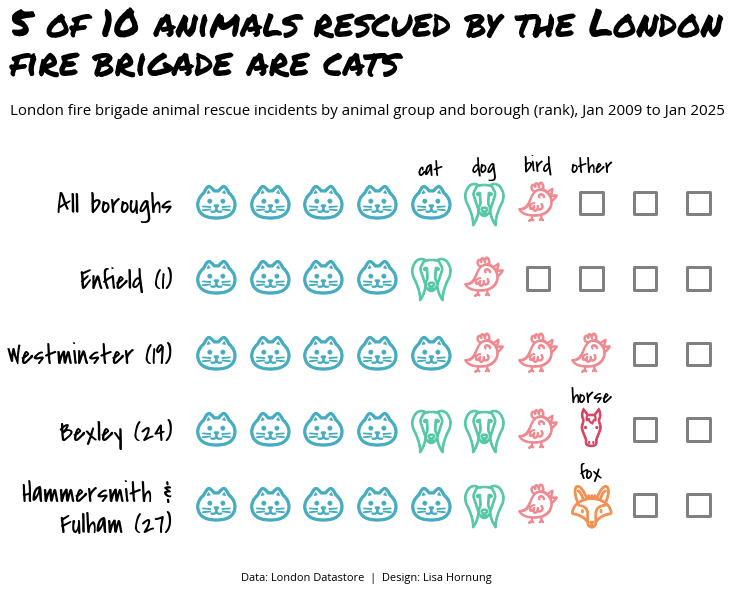

In [125]:
fig, ax = plt.subplots(figsize=(11,7))
plt.subplots_adjust(left=0.23, top=0.78, bottom=0.12)

#parameters
columns = ['cat_fraction','dog_fraction', 'bird_fraction', 'fox_fraction', 'horse_fraction', 'other_fraction']
markers =  [cat_outline_svg, dog_outline_svg, bird_outline_svg, fox_outline_svg, horse_outline_svg, "s"]
sizes = [2000]*5 + [500]
linewidths = [1] *5 + [3]
colors = ["#45ACBF", "#54C7A7", "#F0878E", "#F19050", "#DA4160", "None"]
ecolors = ["#45ACBF", "#54C7A7", "#F0878E", "#F19050", "#DA4160", "grey"]

#plot data----------------
for borough in  boroughs[1:] + [boroughs[0]] :
    data = pivot[pivot.index == borough]
    y_pos = data.index
    x_pos = 1
    for column, marker, color, size, lw, ec in zip(columns, markers, colors, sizes, linewidths, ecolors):
        for i in range(int(data[column][0])):
            plt.scatter(x_pos, y_pos, marker=marker, s=size, linewidth=lw, color=color, edgecolors=ec, clip_on=False)
            x_pos+=1

#format axis---------------
#ax.invert_yaxis()
for pos in ["top", "bottom", "left", "right"]:
    ax.spines[pos].set_visible(False)
ax.set_xticks([])
plt.tick_params(axis='y', which='both', length=0, pad=20)
ax.set_yticklabels([ "Hammersmith &\nFulham (27)", "Bexley (24)","Westminster (19)","Enfield (1)",  "All boroughs",], fontsize=28, font=label_font, )

#legend annotations
ax.text(5,4.35,"cat", font=label_font, fontsize=22, ha="center")
ax.text(6,4.4,"dog", font=label_font, fontsize=22, ha="center")
ax.text(7,4.4,"bird", font=label_font, fontsize=22, ha="center")
ax.text(8,4.4,"other", font=label_font, fontsize=22, ha="center")
ax.text(8,1.35,"horse", font=label_font, fontsize=22, ha="center")
ax.text(8,0.35,"fox", font=label_font, fontsize=22, ha="center")

#title -----------------
fig.text(0,1,"5 of 10 animals rescued by the London\nfire brigade are cats", fontsize=38, font=title_font,linespacing=1.6)
fig.text(0,0.925,"London fire brigade animal rescue incidents by animal group and borough (rank), Jan 2009 to Jan 2025", fontsize=15, font=subtitle_font,linespacing=2)
fig.text(0.45,0,"Data: London Datastore  |  Design: Lisa Hornung", fontsize=11, font=subtitle_font,ha="center")

#export
plt.savefig('2025-day1-animal-rescue-fractions.png', bbox_inches='tight', pad_inches=1, facecolor="white", dpi=120)

plt.show()

## Playground

<AxesSubplot:xlabel='Month'>

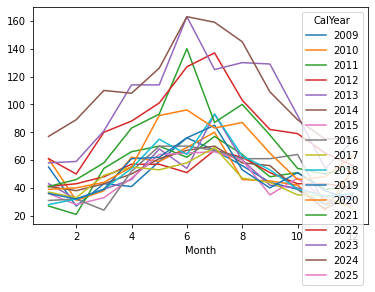

In [41]:
pivot = df
pivot = pivot[["Month","CalYear", ]].value_counts(sort=False).unstack()
pivot.plot()

<AxesSubplot:xlabel='Month'>

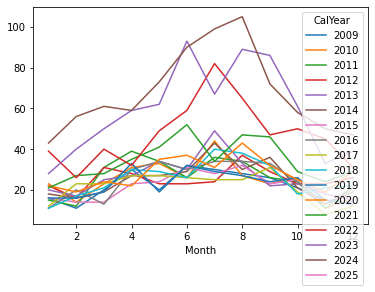

In [ ]:
pivot = df[df["AnimalGroupParent"]=="cat"]
pivot = pivot[["Month","CalYear", ]].value_counts(sort=False).unstack()
pivot.plot()

<AxesSubplot:xlabel='Month'>

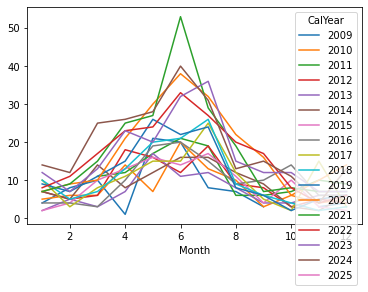

In [36]:
pivot = df[df["AnimalGroupParent"]=="bird"]
pivot = pivot[["Month","CalYear", ]].value_counts(sort=False).unstack()
pivot.plot()

In [40]:
pivot = df[(df["AnimalGroupParent"]=="bird") & (df["Month"]==6) & (df["CalYear"]==2021)]
pivot["Borough"].value_counts()

ealing                    6
greenwich                 4
camden                    3
kingston upon thames      3
barnet                    3
islington                 3
hillingdon                2
harrow                    2
newham                    2
merton                    2
tower hamlets             2
waltham forest            2
enfield                   2
haringey                  2
kensington and chelsea    2
richmond upon thames      2
southwark                 2
brent                     2
barking and dagenham      1
hammersmith and fulham    1
bromley                   1
havering                  1
wandsworth                1
lewisham                  1
westminster               1
Name: Borough, dtype: int64

In [ ]:
#colors = ["#88A0DCFF", "#381A61FF", "#7C4B73FF", "#E78429FF", "#AB3329FF", "None"]
#colors = ["#88A0DCFF", "#381A61FF", "#7C4B73FF", "#ED968CFF", "#AB3329FF", "#E78429FF", "#F9D14AFF"]
#colors = ["#415521FF", "#97AD3DFF", "#4C3425FF", "#7F6552FF", "#5A8093FF", "None"]
#415521FF, #97AD3DFF, #4C3425FF, #7F6552FF, #5A8093FF, #9FBAD3FF

In [107]:
df["AnimalGroupParent"].value_counts().head(5)

cat                                 6083
bird                                2296
dog                                 1635
fox                                  661
unknown - domestic animal or pet     250
Name: AnimalGroupParent, dtype: int64

In [5]:
pivot = df.groupby(["AnimalGroupParent", "CalYear"])["IncidentNumber"].count().unstack()
#pivot = pivot / pivot.sum()*10
pivot = np.floor(pivot / pivot.sum()*10).reset_index()
pivot = pivot[pivot["AnimalGroupParent"].isin(["bird", "cat", "dog"])]
pivot

CalYear,AnimalGroupParent,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,bird,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0
3,cat,4.0,4.0,4.0,5.0,5.0,5.0,4.0,4.0,4.0,5.0,4.0,4.0,4.0,5.0,5.0,6.0,7.0
6,dog,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [56]:
pivot = df[df["CalYear"]>2008].groupby(["Borough","AnimalGroupParent"])["IncidentNumber"].count().unstack()
pivot["total"] = pivot.sum(axis=1)
pivot = pivot[["bird", "cat", "dog", "fox","horse","total"]]
pivot["cat_fraction"] = np.floor(pivot["cat"] / pivot["total"]*10)
pivot["dog_fraction"] = np.floor(pivot["dog"] / pivot["total"]*10)
pivot["bird_fraction"] = np.floor(pivot["bird"] / pivot["total"]*10)
pivot["fox_fraction"] = np.floor(pivot["fox"] / pivot["total"]*10)
pivot["horse_fraction"] = np.floor(pivot["horse"] / pivot["total"]*10)
pivot = pivot.sort_values(by="total", ascending=False)
pivot

AnimalGroupParent,bird,cat,dog,fox,horse,total,cat_fraction,dog_fraction,bird_fraction,fox_fraction,horse_fraction
Borough,,,,,,,,,,,
enfield,85.0,248.0,82.0,23.0,30.0,534.0,4.0,1.0,1.0,0.0,0.0
croydon,105.0,233.0,60.0,30.0,12.0,487.0,4.0,1.0,2.0,0.0,0.0
southwark,111.0,259.0,47.0,41.0,NaN,479.0,5.0,0.0,2.0,0.0,NaN
barnet,98.0,201.0,89.0,29.0,1.0,471.0,4.0,1.0,2.0,0.0,0.0
tower hamlets,82.0,258.0,61.0,35.0,NaN,463.0,5.0,1.0,1.0,0.0,NaN
newham,60.0,277.0,31.0,34.0,1.0,425.0,6.0,0.0,1.0,0.0,0.0
haringey,65.0,271.0,46.0,21.0,1.0,423.0,6.0,1.0,1.0,0.0,0.0
waltham forest,97.0,208.0,53.0,13.0,20.0,422.0,4.0,1.0,2.0,0.0,0.0
bromley,77.0,183.0,78.0,16.0,28.0,416.0,4.0,1.0,1.0,0.0,0.0


In [ ]:
pivot = df[df["CalYear"]>2009].groupby(["PropertyCategory","AnimalGroupParent"])["IncidentNumber"].count().unstack()
pivot["total"] = pivot.sum(axis=1)
pivot = pivot[["bird", "cat", "dog", "fox","horse","total"]]
pivot["cat_fraction"] = np.floor(pivot["cat"] / pivot["total"]*10)
pivot["dog_fraction"] = np.floor(pivot["dog"] / pivot["total"]*10)
pivot["bird_fraction"] = np.floor(pivot["bird"] / pivot["total"]*10)
pivot["fox_fraction"] = np.floor(pivot["fox"] / pivot["total"]*10)
pivot = pivot.sort_values(by="total", ascending=False)
pivot

AnimalGroupParent,bird,cat,dog,fox,horse,total,cat_fraction,dog_fraction,bird_fraction,fox_fraction
PropertyCategory,,,,,,,,,,
dwelling,1081.0,3723.0,534.0,285.0,NaN,6014.0,6.0,0.0,1.0,0.0
outdoor,434.0,1129.0,592.0,185.0,161.0,2739.0,4.0,2.0,1.0,0.0
non residential,427.0,424.0,103.0,74.0,29.0,1123.0,3.0,0.0,3.0,0.0
outdoor structure,253.0,213.0,155.0,94.0,8.0,813.0,2.0,1.0,3.0,1.0
road vehicle,3.0,311.0,114.0,4.0,11.0,460.0,6.0,2.0,0.0,0.0
other residential,8.0,19.0,3.0,3.0,NaN,35.0,5.0,0.0,2.0,0.0
boat,1.0,1.0,2.0,NaN,NaN,4.0,2.0,5.0,2.0,NaN
